In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')
df.head(10)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [ ]:
import pandas as pd

# 1. Cleaning: Convert Mean Score to numeric, coercing 's' to NaN and dropping them
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')
df_clean = df.dropna(subset=['Mean Score']).copy()

# 2. Define entities for comparison using DBN
target_school_dbn = "21K098"
# Dynamically get the school name from the DBN
target_school_name = df_clean[df_clean['School DBN'] == target_school_dbn]['School Name'].iloc[0]

# Filter datasets based on DBN
school_df = df_clean[df_clean['School DBN'] == target_school_dbn]
# Brooklyn others (DBN contains 'K')
brooklyn_others = df_clean[(df_clean['School DBN'].str.contains('K')) & (df_clean['School DBN'] != target_school_dbn)]
all_other_schools = df_clean[df_clean['School DBN'] != target_school_dbn]

# 3. Enhanced Descriptive Statistics
stats_summary = pd.DataFrame({
    target_school_name: school_df['Mean Score'].describe(),
    'Brooklyn (Others)': brooklyn_others['Mean Score'].describe(),
    'Citywide (Others)': all_other_schools['Mean Score'].describe()
})

stats_summary.loc['median'] = [
    school_df['Mean Score'].median(),
    brooklyn_others['Mean Score'].median(),
    all_other_schools['Mean Score'].median()
]

print(f'Comprehensive Descriptive Statistics Comparison for {target_school_name} ({target_school_dbn}):')
display(stats_summary.sort_index())

Comprehensive Descriptive Statistics Comparison for I.S. 98 Bay Academy (21K098):


,I.S. 98 Bay Academy,Brooklyn (Others),Citywide (Others)
25%,89.050000,57.400000,58.300000
50%,90.600000,64.300000,65.400000
75%,92.700000,72.100000,73.400000
count,75.000000,38619.000000,137034.000000
max,95.200000,96.800000,98.700000
mean,89.412000,64.773283,65.986152
median,90.600000,64.300000,65.400000
min,78.600000,15.000000,15.000000
std,4.679367,10.998328,11.278147


In [ ]:
def search_schools(prefix):
    """Returns a list of unique school names starting with the given prefix."""
    matches = df[df['School Name'].str.startswith(prefix, na=False)]['School Name'].unique()
    return sorted(list(matches))

# Example usage:
print('Schools starting with "P.S. 199":')
display(search_schools('P.S. 199'))

Schools starting with "P.S. 199":


[]

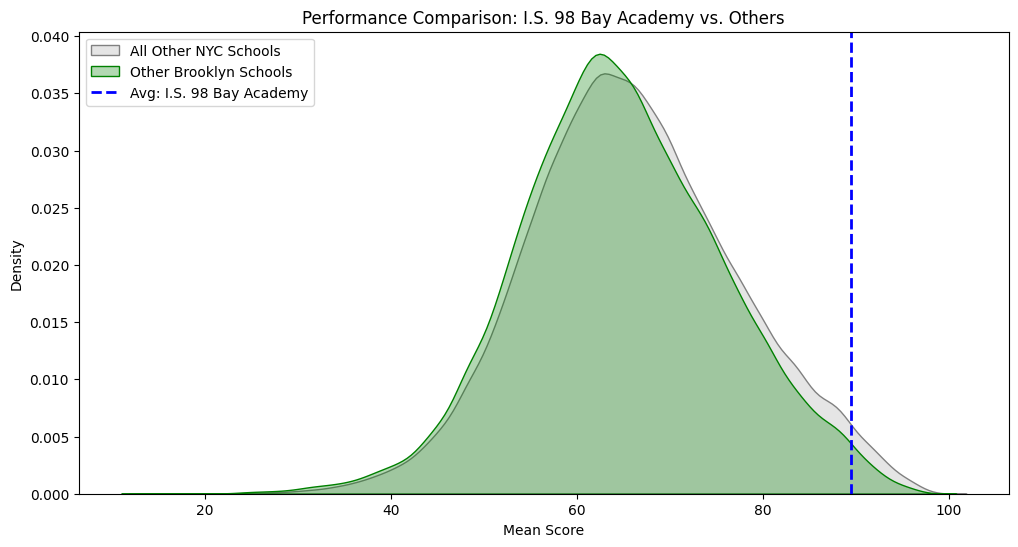

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 4. Visualization: Comparing distributions
sns.kdeplot(all_other_schools['Mean Score'], label='All Other NYC Schools', fill=True, color='gray', alpha=0.2)
sns.kdeplot(brooklyn_others['Mean Score'], label='Other Brooklyn Schools', fill=True, color='green', alpha=0.3)
plt.axvline(school_df['Mean Score'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Avg: {target_school_name}')

plt.title(f'Performance Comparison: {target_school_name} vs. Others')
plt.xlabel('Mean Score')
plt.ylabel('Density')
plt.legend()
plt.show()

### Conclusion

I.S. 98 Bay Academy demonstrates exceptional performance with a Mean Score of approximately 89.4, which significantly exceeds both the Brooklyn and Citywide averages. The school maintains high consistency across exams, evidenced by a median score of 90.6 and a standard deviation much lower than the citywide distribution. Consequently, the analysis and visualizations confirm that this institution sits at the far right of the performance distribution, outperforming the vast majority of NYC schools.